<a href="https://colab.research.google.com/github/Arvind13s/Oil-Spill-Detection-Using-Satellite-Images/blob/main/oil_spill_using_pretrained.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q kaggle



In [2]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam


In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"arvindsingh13","key":"3149c462e6e5919c4c381d5c58400b9a"}'}

In [4]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle datasets download -d vighneshanand/oil-spill-dataset-binary-image-classification -p /content/data


Dataset URL: https://www.kaggle.com/datasets/vighneshanand/oil-spill-dataset-binary-image-classification
License(s): unknown
100% 790M/792M [00:03<00:00, 169MB/s]
100% 792M/792M [00:03<00:00, 221MB/s]


In [6]:
!unzip -q /content/data/oil-spill-dataset-binary-image-classification.zip -d /content/data/

In [7]:

import os



In [8]:
data_dir = "/content/data/final dataset used for oil spill/dataset-final/dataset"

train_path = os.path.join(data_dir, "train")
val_path = os.path.join(data_dir, "Validation")
test_path = os.path.join(data_dir, "test")

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(rescale=1./255, horizontal_flip=True, zoom_range=0.2)
val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(train_path, target_size=(224, 224),
                                           batch_size=32, class_mode='binary')
val_data = val_gen.flow_from_directory(val_path, target_size=(224, 224),
                                       batch_size=32, class_mode='binary')
test_data = test_gen.flow_from_directory(test_path, target_size=(224, 224),
                                         batch_size=32, class_mode='binary')


Found 2800 images belonging to 2 classes.
Found 600 images belonging to 2 classes.
Found 600 images belonging to 2 classes.


In [10]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam


In [11]:

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
x = Flatten()(base_model.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)


In [13]:
model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=Adam(1e-4), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,926,209 (68.38 MB)

 Trainable params: 3,211,521 (12.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [14]:
history = model.fit(train_data, validation_data=val_data, epochs=10)


Epoch 1/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 97s 930ms/step - accuracy: 0.8104 - loss: 0.4068 - val_accuracy: 0.9033 - val_loss: 0.2483
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 62s 699ms/step - accuracy: 0.9364 - loss: 0.1849 - val_accuracy: 0.9383 - val_loss: 0.1910
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 61s 698ms/step - accuracy: 0.9629 - loss: 0.1285 - val_accuracy: 0.9600 - val_loss: 0.1346
Epoch 4/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 63s 715ms/step - accuracy: 0.9746 - loss: 0.0998 - val_accuracy: 0.9683 - val_loss: 0.1162
Epoch 5/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 63s 717ms/step - accuracy: 0.9807 - loss: 0.0764 - val_accuracy: 0.9733 - val_loss: 0.0989
Epoch 6/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 65s 741ms/step - accuracy: 0.9818 - loss: 0.0691 - val_accuracy: 0.9433 - val_loss: 0.1456
Epoch 7/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 65s 741ms/step - accuracy: 0.9871 - loss: 0.0614 - val_accuracy: 0.9617 - val_loss: 0.0987
Epoch 8/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 64s 732ms/step - accuracy: 0.9904 - loss: 0.0448 - val_accu

In [15]:
base_model.trainable = True
model.compile(optimizer=Adam(1e-5), loss='binary_crossentropy', metrics=['accuracy'])
model.fit(train_data, validation_data=val_data, epochs=5)

Epoch 1/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.9889 - loss: 0.0351 - val_accuracy: 0.9800 - val_loss: 0.0507
Epoch 2/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 78s 884ms/step - accuracy: 0.9968 - loss: 0.0117 - val_accuracy: 0.9883 - val_loss: 0.0303
Epoch 3/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 75s 852ms/step - accuracy: 0.9996 - loss: 0.0042 - val_accuracy: 0.9950 - val_loss: 0.0169
Epoch 4/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 79s 892ms/step - accuracy: 0.9925 - loss: 0.0201 - val_accuracy: 0.9817 - val_loss: 0.0366
Epoch 5/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 74s 836ms/step - accuracy: 0.9986 - loss: 0.0054 - val_accuracy: 0.9933 - val_loss: 0.0193


In [16]:
loss, acc = model.evaluate(test_data)
print(f"VGG16 Test Accuracy: {acc * 100:.2f}%")



19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 259ms/step - accuracy: 0.9967 - loss: 0.0127
VGG16 Test Accuracy: 99.67%


In [17]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:

y_true = test_data.classes

In [19]:
y_pred_probs = model.predict(test_data)
y_pred = (y_pred_probs > 0.5).astype("int32").flatten()


19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 358ms/step


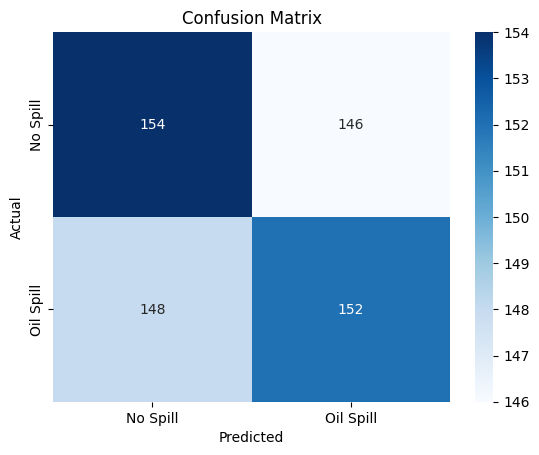

In [20]:
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Spill', 'Oil Spill'], yticklabels=['No Spill', 'Oil Spill'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [21]:
print(classification_report(y_true, y_pred, target_names=['No Spill', 'Oil Spill']))


              precision    recall  f1-score   support

    No Spill       0.51      0.51      0.51       300
   Oil Spill       0.51      0.51      0.51       300

    accuracy                           0.51       600
   macro avg       0.51      0.51      0.51       600
weighted avg       0.51      0.51      0.51       600



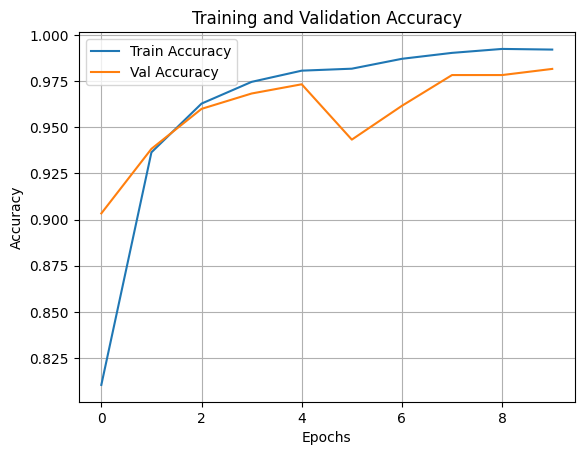

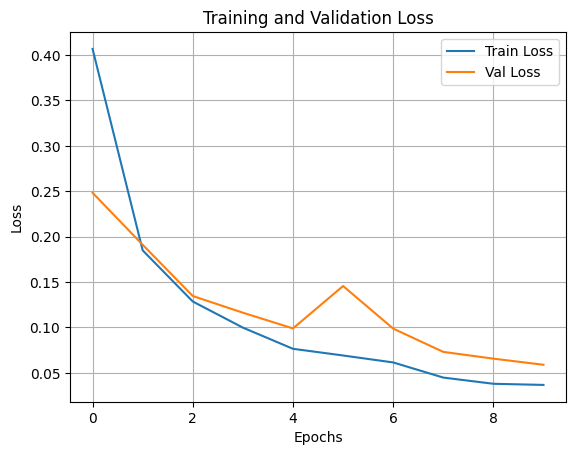

In [22]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
model.save("oilspill_model.h5")


In [24]:
from google.colab import files
files.download('oilspill_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>